## Hướng dẫn sử dụng Notebook OULAD_FE2.ipynb

Notebook này thực hiện **Feature Engineering** cho dataset OULAD (Open University Learning Analytics Dataset) để dự báo kết quả học tập của sinh viên (4 lớp: Pass, Fail, Withdrawn, Distinction), với trọng tâm phát hiện sớm nhóm Withdrawn.

### Cách chạy:
1. **Chuẩn bị môi trường**: Đảm bảo đã cài đặt các thư viện cần thiết (pandas, numpy, scikit-learn). Chạy `pip install pandas numpy scikit-learn` nếu chưa có.
2. **Load dữ liệu**: Các file CSV (assessments.csv, studentInfo.csv, v.v.) phải nằm trong thư mục `../../data/`. Nếu đường dẫn khác, sửa `DATAPATH`.
3. **Chạy tuần tự các cell**:
   - **Session 0**: Thiết lập chung (load data, set constants).
   - **Session 1-5**: Xử lý dữ liệu và tạo tính năng (chạy theo thứ tự để tránh lỗi).
   - **Session 6**: Chia tập train/test và scaling.
   - **Session 7**: Xuất dữ liệu (tùy chọn).
4. **Kiểm tra lỗi**: Nếu gặp lỗi (ví dụ: KeyError, ValueError), kiểm tra các cell trước đó đã chạy thành công chưa.
5. **Xuất kết quả**: Sau khi chạy xong, dữ liệu đã xử lý sẽ lưu trong `df_master`, `df_train`, `df_test`.

### Lưu ý quan trọng:
- **Thứ tự thực thi**: Tuân thủ nghiêm ngặt thứ tự session để tránh rò rỉ dữ liệu.
- **CUTOFF_DAY**: Đặt là 135 (ngày cắt dữ liệu để dự báo sớm).
- **Scaling**: Chỉ áp dụng cho mô hình tuyến tính; mô hình cây (RF, XGBoost) dùng dữ liệu gốc.
- **Edge cases**: Xử lý đặc biệt cho module GGG, AAA, EEE như mô tả.
- **Tái lập**: RANDOM_SEED = 42 đảm bảo kết quả nhất quán.

### Output:
- `df_master`: Bảng dữ liệu đầy đủ sau feature engineering.
- `df_train` / `df_test`: Tập train/test sau split.
- File CSV: Xuất từ session 7 nếu cần.

Nếu gặp vấn đề, kiểm tra console lỗi hoặc liên hệ để debug.

# 0. Thiết lập chung
*   Tải toàn bộ dataset
*   CUTOFF_DAY: 135 (Điểm cắt dữ liệu để dự báo).
*   RANDOM_SEED: 42 (Dùng xuyên suốt toàn bộ pipeline để đảm bảo tính tái lập).
*   Mục tiêu: Phân loại 4 lớp (Pass / Fail / Withdrawn / Distinction), ưu tiên tối đa việc phát hiện sớm nhóm Withdrawn.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# --- 0. THIẾT LẬP CHUNG ---
CUTOFF_DAY = 135
RANDOM_SEED = 42

DATAPATH = "../../data/"
df_assessments = pd.read_csv(DATAPATH + 'assessments.csv')
df_studentInfo = pd.read_csv(DATAPATH + 'studentInfo.csv')
df_studentAssessment = pd.read_csv(DATAPATH + 'studentAssessment.csv')
df_studentRegistration = pd.read_csv(DATAPATH + 'studentRegistration.csv')
df_studentVle = pd.read_csv(DATAPATH + 'studentVle.csv')
df_courses = pd.read_csv(DATAPATH + 'courses.csv')
df_vle = pd.read_csv(DATAPATH + 'vle.csv')

target_map = {
    'Pass' : 0,
    'Fail' : 1,
    'Withdrawn' : 2,
    'Distinction' : 3
}

df_studentInfo['target'] = df_studentInfo['final_result'].map(target_map)
print(df_studentInfo['target'].value_counts())

target
0    12361
2    10156
1     7052
3     3024
Name: count, dtype: int64


# 1. Tiền xử lý dữ liệu & Làm sạch (Semantic Nulls)

*   **`date_registration`**: Điền các giá trị thiếu bằng giá trị trung vị (median) của đợt học tương ứng.
*   **`imd_band`**: Chuyển đổi các giá trị NULL thành nhãn "Unknown" (gán giá trị 10, cuối thang đo).
*   **`score`**: Điền giá trị 0 cho các cột điểm bị trống (NULL = không nộp bài).
*  **Loại bỏ cột nhiễu**: Xóa bỏ `week_from`, `week_to` (tỷ lệ trống cao) và `date_unregistration` (tránh rò rỉ dữ liệu).

In [2]:
# Điền giá trị NaN trong cột 'date_registration' bằng giá trị trung vị của nhóm tương ứng
df_studentRegistration['date_registration'] = pd.to_numeric(df_studentRegistration['date_registration'], errors='coerce')
df_studentRegistration['date_registration'] = df_studentRegistration.groupby(['code_module', 'code_presentation'])['date_registration'].transform(lambda x: x.fillna(x.median()))

# Nếu cột 'date_unregistration' tồn tại, loại bỏ nó
if 'date_unregistration' in df_studentRegistration.columns:
    df_studentRegistration = df_studentRegistration.drop(columns=['date_unregistration'])

# Điền giá trị NaN trong cột 'imd_band' bằng 'Unknown'
df_studentInfo['imd_band'] = df_studentInfo['imd_band'].fillna('Unknown')
# Điền giá trị NaN trong cột 'age_band' bằng 'Unknown'

df_studentInfo['age_band'] = df_studentInfo['age_band'].fillna('Unknown')

# Nếu cột 'week_from' và 'week_to' tồn tại, loại bỏ chúng
if ('week_from' in df_vle.columns) and ('week_to' in df_vle.columns):
  df_vle = df_vle.drop(columns=['week_from', 'week_to'])

# Điền giá trị NaN trong cột 'score' của df_studentAssessment bằng 0
df_studentAssessment['score'] = df_studentAssessment['score'].fillna(0)

# 2. Nhóm tính năng động lực trước khóa học (Pre-Course Engagement)

Đo lường sự chuẩn bị của sinh viên trước ngày khai giảng (ngày < 0):

*   **`pre_course_clicks`**: Tổng lượng tương tác của sinh viên trước ngày 0.
*   **`pre_course_active_days`**: Số ngày sinh viên truy cập hệ thống trước ngày 0.
*   **`has_pre_course_activity`**: Biến nhị phân xác định sinh viên có chuẩn bị sớm hay không.

In [3]:
# Tinh năng về hoạt động trước khóa học
# Lọc các hoạt động trong df_studentVle có ngày âm (trước ngày bắt đầu khóa học)
pre_courses_vle = df_studentVle[df_studentVle['date'] < 0].copy()

# Tính tổng số lần click và số ngày hoạt động trước khóa học cho mỗi sinh viên
pre_courses_engagement = pre_courses_vle.groupby(['id_student']).agg(
    pre_course_clicks = ('sum_click', 'sum'),
    pre_course_active_days = ('date', 'nunique')
).reset_index()

# Kết hợp thông tin này vào df_studentInfo
df_studentInfo = df_studentInfo.drop(columns=['pre_course_clicks', 'pre_course_active_days'], errors='ignore')
df_studentInfo = df_studentInfo.merge(pre_courses_engagement, on='id_student', how='left')
df_studentInfo[['pre_course_clicks', 'pre_course_active_days']] = df_studentInfo[['pre_course_clicks', 'pre_course_active_days']].fillna(0)
df_studentInfo['has_pre_course_activity'] = (df_studentInfo['pre_course_active_days'] > 0).astype(int)

# 3. Nhóm tính năng tương tác VLE (Temporal Features)

Tập trung vào đặc trưng hành vi biến thiên của sinh viên tính đến ngày `CUTOFF_DAY`:

*   **`last_active_day`**: Ngày tương tác cuối cùng (chỉ số quan trọng nhất để nhận diện sinh viên `Withdrawn`).
*   **`std_clicks`**: Độ lệch chuẩn lượng click hàng ngày để đo tính kỷ luật và đều đặn trong học tập.
*   **`active_days`**: Tổng số ngày thực tế có tương tác trên hệ thống.
*   **`Weekly Clicks`**: Tạo 20 cột (`clicks_week_1` đến `clicks_week_20`) dựa trên `ceil(CUTOFF_DAY / 7)`. Điền 0 cho các tuần không hoạt động.
*   **`Activity Breakdown`**: Tách riêng lượng click của các tài nguyên quan trọng:
    *   `clicks_oucontent`: Nội dung bài học chính.
    *   `clicks_forumng`: Tương tác diễn đàn (thường tương quan cao với kết quả `Pass`).
    *   `clicks_quiz`, `clicks_resource`: Các tín hiệu bổ trợ khác từ các loại hoạt động này.

In [4]:
# Tính năng về hoạt động trước cutoff
df_days_before_cutoff = df_studentVle[df_studentVle['date'] <= CUTOFF_DAY].copy()
df_vle_before_cutoff = df_days_before_cutoff.groupby(['id_student']).agg(
    last_active_day = ('date', 'max'),
    std_clicks = ('sum_click', 'std'),
    active_days = ('date', 'nunique')
).reset_index()

# Tính số lần click mỗi tuần trước cutoff
df_days_before_cutoff['week'] = np.ceil(df_days_before_cutoff['date']/7).astype(int)
weekly = df_days_before_cutoff.pivot_table(
    index='id_student',
    columns='week',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
)
weekly.columns=[f'clicks_week_{int(c)}' for c in weekly.columns]

# Tính số lần click theo loại hoạt động trước cutoff
df_detail_studentVle = df_days_before_cutoff.merge(df_vle[['id_site', 'activity_type']], on='id_site', how='left')
df_activity_breakdown = df_detail_studentVle.pivot_table(
    index='id_student',
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
)
df_activity_breakdown = df_activity_breakdown[['oucontent', 'forumng', 'quiz', 'resource']]
df_activity_breakdown.columns = [f'clicks_{c}' for c in df_activity_breakdown.columns]
df_studentInfo = df_studentInfo.merge(df_vle_before_cutoff, on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(weekly.reset_index(), on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(df_activity_breakdown.reset_index(), on='id_student', how='left')

# Điền giá trị NaN cho các cột mới tạo bằng 0
vle_cols = ['last_active_day', 'std_clicks', 'active_days'] + list(weekly.columns) + list(df_activity_breakdown.columns)
for col in vle_cols:
    if col in df_studentInfo.columns:
        df_studentInfo[col] = df_studentInfo[col].fillna(0)

# Merge các df đã xử lý

In [5]:
# module 1
print(f'df_studentInfo.columns:         {df_studentInfo.columns.tolist()}')
print(f'df_studentAssessment.columns:   {df_studentAssessment.columns.tolist()}')
print(f'df_studentRegistration.columns: {df_studentRegistration.columns.tolist()}')
print(f'df_vle.columns:                 {df_vle.columns.tolist()}')

# module 2
print("-"*40)
print(f'pre_courses_engagement.columns: {pre_courses_engagement.columns.tolist()}')
print(f'pre_courses_vle.columns:        {pre_courses_vle.columns.tolist()}')

# module 3
print("-"*40)
print(f'df_days_before_cutoff.columns:  {df_days_before_cutoff.columns.tolist()}')
print(f'df_vle_before_cutoff.columns:   {df_vle_before_cutoff.columns.tolist()}')
print(f'weekly.columns:                 {weekly.columns.tolist()}')
print(f'df_activity_breakdown.columns:  {df_activity_breakdown.columns.tolist()}')

df_studentInfo.columns:         ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target', 'pre_course_clicks', 'pre_course_active_days', 'has_pre_course_activity', 'last_active_day', 'std_clicks', 'active_days', 'clicks_week_-3', 'clicks_week_-2', 'clicks_week_-1', 'clicks_week_0', 'clicks_week_1', 'clicks_week_2', 'clicks_week_3', 'clicks_week_4', 'clicks_week_5', 'clicks_week_6', 'clicks_week_7', 'clicks_week_8', 'clicks_week_9', 'clicks_week_10', 'clicks_week_11', 'clicks_week_12', 'clicks_week_13', 'clicks_week_14', 'clicks_week_15', 'clicks_week_16', 'clicks_week_17', 'clicks_week_18', 'clicks_week_19', 'clicks_week_20', 'clicks_oucontent', 'clicks_forumng', 'clicks_quiz', 'clicks_resource']
df_studentAssessment.columns:   ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']
df_studentRegistration.columns: ['code_module', '

In [6]:
# Bước 1: Khởi tạo df_master từ df_studentInfo (bảng trung tâm chứa nhiều tính năng nhất)
df_master = df_studentInfo.copy()

# Bước 2: Merge với df_studentRegistration
# Ta dùng 3 key chung để đảm bảo map chính xác sinh viên vào đúng môn học (module) và học kỳ (presentation)
df_master = pd.merge(
    df_master, 
    df_studentRegistration[['code_module', 'code_presentation', 'id_student', 'date_registration']], 
    on=['code_module', 'code_presentation', 'id_student'], 
    how='left'
)

# Bước 3: Xử lý và Merge với df_studentAssessment
# LƯU Ý QUAN TRỌNG: df_studentAssessment không có code_module và code_presentation, chỉ có id_student. 
# Do 1 sinh viên có thể có nhiều bài kiểm tra, ta CẦN aggregate (gom nhóm) dữ liệu trước khi merge để tránh làm nhân bản số dòng trong df_master.
df_studentAssessment['id_student'] = pd.to_numeric(df_studentAssessment['id_student'], errors='coerce')
df_studentAssessment['score'] = pd.to_numeric(df_studentAssessment['score'], errors='coerce')
df_assessment_agg = df_studentAssessment.groupby('id_student').agg(
    mean_score=('score', 'mean'),             # Tính điểm trung bình của sinh viên
    total_assessments=('id_assessment', 'count') # Đếm tổng số bài kiểm tra đã nộp
).reset_index()

# Merge bảng điểm đã gom nhóm vào master
df_master = pd.merge(
    df_master, 
    df_assessment_agg, 
    on='id_student', 
    how='left'
)

# (Tùy chọn) Điền các giá trị điểm bị thiếu bằng 0 hoặc trung vị nếu sinh viên chưa có bài thi nào
df_master['mean_score'] = df_master['mean_score'].fillna(0)
df_master['total_assessments'] = df_master['total_assessments'].fillna(0)

## 4. Nhóm tính năng đánh giá & Học tập (Assessment Features)
Quy tắc xác định **Safe Assessment**: Chỉ tính các bài có `deadline <= CUTOFF_DAY`. Toàn bộ bài thi cuối kỳ (Exam) bị loại bỏ vì gây rò rỉ dữ liệu 100%.

* **weighted_score_before_cutoff**: Tính theo công thức `sum(score × weight) / sum(weight)`.
* **tma_submission_rate & cma_submission_rate**: 
   * Công thức: `n_submitted / n_safe_in_module`.
   * Nếu module không có loại bài đó trước ngày 135: Điền `-1`.
   * Nếu có bài nhưng sinh viên không nộp: Điền `0`.
* **avg_days_before_deadline**: Trung bình số ngày nộp trước hạn (Giữ nguyên giá trị âm nếu nộp trễ, không thực hiện clip).
* **n_missing_submission**: Tổng số bài đánh giá "Safe" mà sinh viên bỏ lỡ.
* **Xử lý Edge Cases**:
   * **Module GGG**: Do trọng số TMA = 0 nên không tính được điểm tích lũy. Thêm cột `has_weighted_score = 0` để mô hình phân biệt và sử dụng `TMA submission count` làm tín hiệu thay thế.
   * **Module AAA, EEE**: Điền `-1` cho `cma_submission_rate` do không có bài CMA trước ngày 135.

In [7]:
# Lọc bài đánh giá an toàn: deadline <= CUTOFF_DAY và không phải Exam
df_assessments['date'] = pd.to_numeric(df_assessments['date'], errors='coerce')
safe_assessments = df_assessments[
    (df_assessments['date'] <= CUTOFF_DAY) & 
    (df_assessments['assessment_type'] != 'Exam')
].copy()

# Gộp studentAssessment với safe_assessments
df_student_assessment_safe = pd.merge(
    df_studentAssessment, 
    safe_assessments[['id_assessment', 'code_module', 'date', 'weight', 'assessment_type']],  # Thêm code_module
    on='id_assessment', 
    how='inner'
)

# Tính weighted_score_before_cutoff
weighted_scores = df_student_assessment_safe.groupby('id_student').apply(
    lambda x: (x['score'] * x['weight']).sum() / x['weight'].sum() if x['weight'].sum() > 0 else 0
).reset_index(name='weighted_score_before_cutoff')

# Tính tỷ lệ nộp bài cho TMA và CMA
total_safe_per_module_type = safe_assessments.groupby(['code_module', 'assessment_type']).size().reset_index(name='total_safe')
submitted_per_student = df_student_assessment_safe.groupby(['id_student', 'code_module', 'assessment_type']).size().reset_index(name='submitted')
submission_rates = pd.merge(
    submitted_per_student, 
    total_safe_per_module_type, 
    on=['code_module', 'assessment_type'], 
    how='right'
)
submission_rates['submitted'] = submission_rates['submitted'].fillna(0)
submission_rates['submission_rate'] = submission_rates['submitted'] / submission_rates['total_safe']
submission_rates_pivot = submission_rates.pivot_table(
    index=['id_student', 'code_module'], 
    columns='assessment_type', 
    values='submission_rate'
).reset_index()
submission_rates_pivot = submission_rates_pivot.rename(columns={
    'TMA': 'tma_submission_rate', 
    'CMA': 'cma_submission_rate'
})
submission_rates_pivot['tma_submission_rate'] = submission_rates_pivot['tma_submission_rate'].fillna(-1)
submission_rates_pivot['cma_submission_rate'] = submission_rates_pivot['cma_submission_rate'].fillna(-1)

# Tính avg_days_before_deadline
df_student_assessment_safe['days_before_deadline'] = df_student_assessment_safe['date_submitted'] - df_student_assessment_safe['date']
avg_days = df_student_assessment_safe.groupby('id_student')['days_before_deadline'].mean().reset_index(name='avg_days_before_deadline')
avg_days['avg_days_before_deadline'] = avg_days['avg_days_before_deadline'].fillna(0)

# Tính n_missing_submission
missing = submission_rates.copy()
missing['missing'] = missing['total_safe'] - missing['submitted']
n_missing = missing.groupby(['id_student', 'code_module'])['missing'].sum().reset_index(name='n_missing_submission')

# Thêm cột has_weighted_score cho module GGG
weighted_scores['has_weighted_score'] = (weighted_scores['weighted_score_before_cutoff'] > 0).astype(int)

# Merge tất cả tính năng vào df_master cùng lúc
features_to_merge = [
    weighted_scores[['id_student', 'weighted_score_before_cutoff', 'has_weighted_score']],
    submission_rates_pivot[['id_student', 'code_module', 'tma_submission_rate', 'cma_submission_rate']],
    avg_days[['id_student', 'avg_days_before_deadline']],
    n_missing[['id_student', 'code_module', 'n_missing_submission']]
]

for feature_df in features_to_merge:
    df_master = pd.merge(df_master, feature_df, on=feature_df.columns.intersection(['id_student', 'code_module']).tolist(), how='left')

# Điền giá trị thiếu
df_master['weighted_score_before_cutoff'] = df_master['weighted_score_before_cutoff'].fillna(0)
df_master['tma_submission_rate'] = df_master['tma_submission_rate'].fillna(-1)
df_master['cma_submission_rate'] = df_master['cma_submission_rate'].fillna(-1)
df_master['avg_days_before_deadline'] = df_master['avg_days_before_deadline'].fillna(0)
df_master['n_missing_submission'] = df_master['n_missing_submission'].fillna(0)
df_master['has_weighted_score'] = df_master['has_weighted_score'].fillna(0)

# 5. Nhóm tính năng bối cảnh & Nhân khẩu học
* **module_semester**: Kết hợp mã môn và học kỳ (Ví dụ: AAA_B).
* **num_of_prev_attempts**: Giữ nguyên do có tương quan mạnh với rủi ro trượt/rút môn.
* **Loại bỏ**: Xóa tính năng `gender` do không đóng góp giá trị dự báo.
* **Lưu ý**: Encoding sẽ được thực hiện sau khi split dữ liệu (trong session 6) để tránh rò rỉ.

In [8]:
# Tạo module_semester: kết hợp code_module và code_presentation
df_master['module_semester'] = df_master['code_module'] + '_' + df_master['code_presentation']

# Giữ nguyên num_of_prev_attempts
# Không cần thay đổi gì

# Loại bỏ cột gender
df_master = df_master.drop(columns=['gender'], errors='ignore')

## 6. Danh mục kiểm tra & Tiền xử lý (Modeling Prep)
* **Stratified Split**: Chia tập dữ liệu dựa trên nhãn mục tiêu và mã môn học để đảm bảo tính đồng nhất.
* **Student-level Split**: Đảm bảo tất cả bản ghi của cùng một `id_student` phải nằm hoàn toàn trong tập Train hoặc tập Test để tránh rò rỉ thông tin sinh viên.
* **Encoding**: Thực hiện sau split để fit trên tập Train và transform cho cả Train/Test.
  * **Label Encoding**: `module_semester`.
  * **Ordinal Encoding**: `highest_education`, `age_band`, `imd_band`.
* **Scaling**:
    * Với mô hình cây (Random Forest, XGBoost): Không cần scaling.
    * Với mô hình tuyến tính: Sử dụng `StandardScaler`, chỉ **fit trên tập Train** và áp dụng (transform) cho tập Test.

In [ ]:
# Chuẩn bị dữ liệu cho split
# Tạo df với thông tin duy nhất cho mỗi sinh viên
student_info = df_master[['id_student', 'final_result', 'code_module']].drop_duplicates()

# Tạo cột stratify kết hợp final_result và code_module
student_info['stratify_col'] = student_info['final_result'] + '_' + student_info['code_module']

# Stratified split dựa trên cột stratify
train_students, test_students = train_test_split(
    student_info, 
    test_size=0.2, 
    stratify=student_info['stratify_col'], 
    random_state=42
)

# Lấy danh sách id_student cho train và test
train_ids = set(train_students['id_student'])
test_ids = set(test_students['id_student'])

# Chia df_master thành train và test
df_train = df_master[df_master['id_student'].isin(train_ids)].copy()
df_test = df_master[df_master['id_student'].isin(test_ids)].copy()

# Chuẩn bị features cho scaling (loại bỏ các cột không phải feature và cột chuỗi)
exclude_cols = ['id_student', 'code_module', 'code_presentation', 'final_result', 'module_semester', 'highest_education', 'age_band', 'imd_band', 'region', 'disability']
feature_cols = [col for col in df_master.columns if col not in exclude_cols and df_master[col].dtype in ['int64', 'float64']]
# Chỉ giữ lại các cột số (numeric)# Giả sử các cột encoded đã được tạo, và loại bỏ categorical gốc nếu cần

# Encoding sau split (fit trên train, transform cho cả train và test)
from sklearn.preprocessing import LabelEncoder

# Label Encoding cho module_semester
le_module = LabelEncoder()
df_train['module_semester_encoded'] = le_module.fit_transform(df_train['module_semester'])
df_test['module_semester_encoded'] = le_module.transform(df_test['module_semester'])

# Ordinal Encoding cho highest_education
education_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent', 'HE Qualification', 'Post Graduate Qualification']
df_train['highest_education_encoded'] = df_train['highest_education'].map({v: i for i, v in enumerate(education_order)})
df_test['highest_education_encoded'] = df_test['highest_education'].map({v: i for i, v in enumerate(education_order)})

# Tương tự cho age_band và imd_band
age_order = ['0-35', '35-55', '55<=']
df_train['age_band_encoded'] = df_train['age_band'].map({v: i for i, v in enumerate(age_order)})
df_test['age_band_encoded'] = df_test['age_band'].map({v: i for i, v in enumerate(age_order)})

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%', 'Unknown']
df_train['imd_band_encoded'] = df_train['imd_band'].map({v: i for i, v in enumerate(imd_order)})
df_test['imd_band_encoded'] = df_test['imd_band'].map({v: i for i, v in enumerate(imd_order)})

# Loại bỏ cột gender nếu chưa
df_train = df_train.drop(columns=['gender'], errors='ignore')
df_test = df_test.drop(columns=['gender'], errors='ignore')

# Scaling cho mô hình tuyến tính
scaler = StandardScaler()
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

# Fit scaler trên train
scaler.fit(df_train[feature_cols])

# Transform train và test
df_train_scaled[feature_cols] = scaler.transform(df_train[feature_cols])
df_test_scaled[feature_cols] = scaler.transform(df_test[feature_cols])

# Lưu ý: Với mô hình cây, sử dụng df_train và df_test trực tiếp mà không scale

# 7. Phân tích tương quan và Lựa chọn tính năng (Correlation Analysis & Feature Selection)
* **Ma trận tương quan**: Trước khi chọn tính năng, xem ma trận tương quan để hiểu mối quan hệ giữa các tính năng và phát hiện đa cộng tuyến.
* **Mục đích của Feature Selection**: Giảm chiều dữ liệu, loại bỏ tính năng ít quan trọng để cải thiện hiệu suất mô hình và tránh overfitting.
* **Phương pháp**: Sử dụng `SelectKBest` với `mutual_info_classif` để chọn top 20 tính năng quan trọng nhất dựa trên thông tin lẫn nhau với nhãn mục tiêu.
* **Áp dụng**: Fit trên tập Train, transform cho cả Train và Test.

In [12]:
print(f'Train shape: {df_train.shape}, Test shape: {df_test.shape}')
print(f"Train set size: {df_train.shape[0]} samples")
print(f"Test set size: {df_test.shape[0]} samples")
print(f"Train features: {feature_cols}")

Train shape: (27130, 60), Test shape: (7590, 60)
Train set size: 27130 samples
Test set size: 7590 samples
Train features: ['num_of_prev_attempts', 'studied_credits', 'target', 'pre_course_clicks', 'pre_course_active_days', 'has_pre_course_activity', 'last_active_day', 'std_clicks', 'active_days', 'clicks_week_-3', 'clicks_week_-2', 'clicks_week_-1', 'clicks_week_0', 'clicks_week_1', 'clicks_week_2', 'clicks_week_3', 'clicks_week_4', 'clicks_week_5', 'clicks_week_6', 'clicks_week_7', 'clicks_week_8', 'clicks_week_9', 'clicks_week_10', 'clicks_week_11', 'clicks_week_12', 'clicks_week_13', 'clicks_week_14', 'clicks_week_15', 'clicks_week_16', 'clicks_week_17', 'clicks_week_18', 'clicks_week_19', 'clicks_week_20', 'clicks_oucontent', 'clicks_forumng', 'clicks_quiz', 'clicks_resource', 'date_registration', 'mean_score', 'total_assessments', 'weighted_score_before_cutoff', 'has_weighted_score', 'tma_submission_rate', 'cma_submission_rate', 'avg_days_before_deadline', 'n_missing_submission']

(27130, 46)


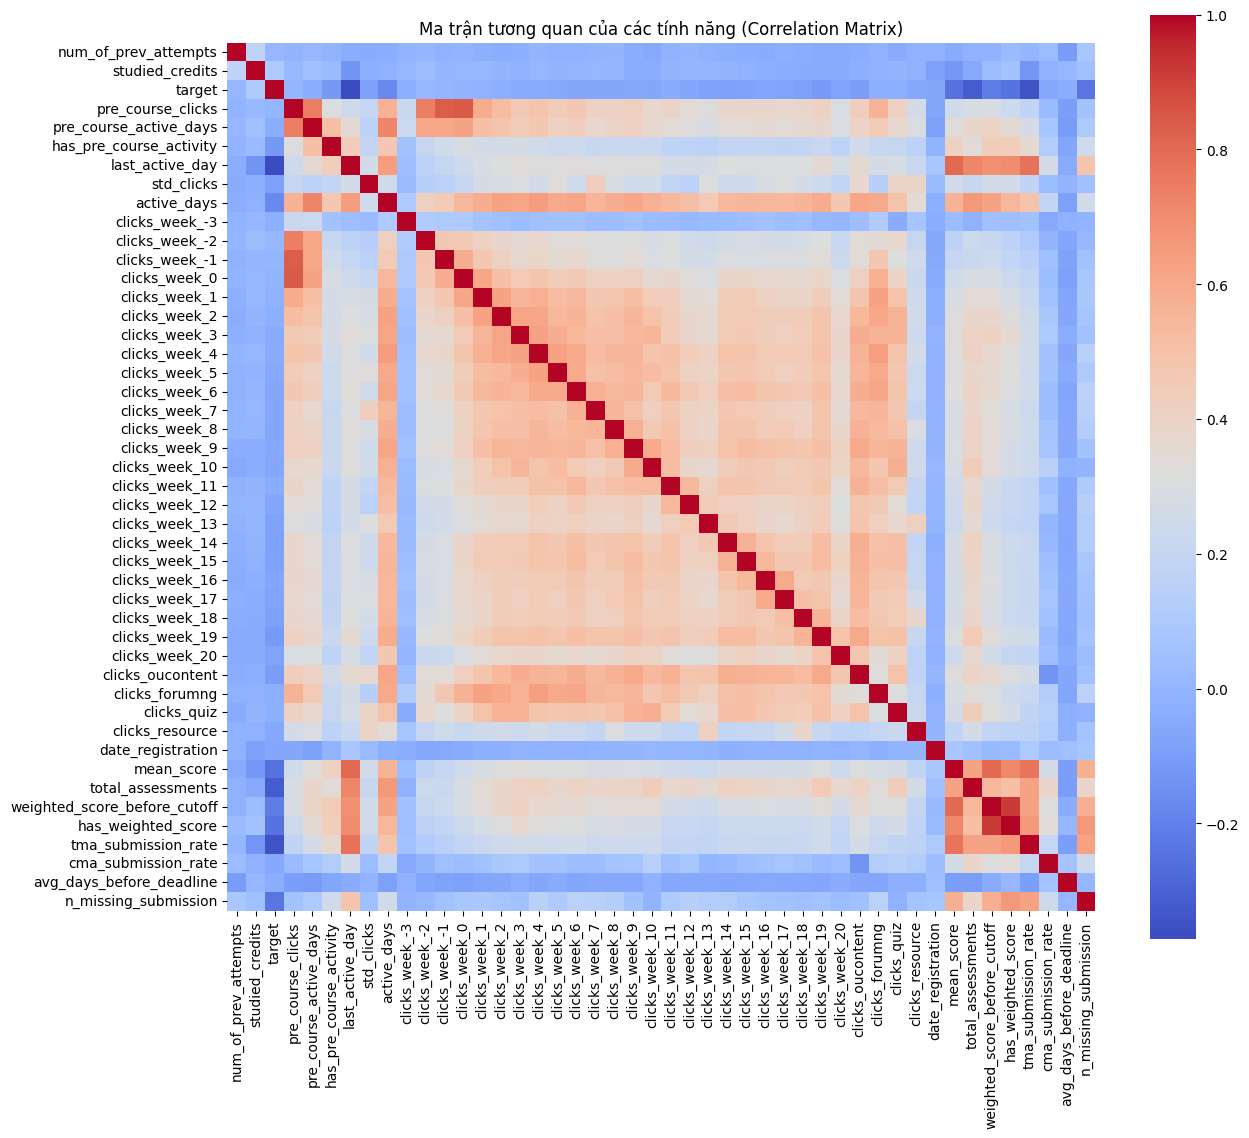

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

X_train = df_train_scaled[feature_cols]
print(X_train.shape)
y_train = df_train_scaled['target']
# Tính ma trận tương quan trên tập train đã impute
X_train = df_train_scaled[feature_cols]
corr_matrix = pd.DataFrame(X_train, columns=feature_cols).corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', square=True)
plt.title('Ma trận tương quan của các tính năng (Correlation Matrix)')
plt.show()

# Nếu muốn xem dưới dạng bảng, uncomment dòng dưới
# print(corr_matrix)

In [ ]:
# Có thể bỏ qua nếu muốn dùng tất cả tính năng, hoặc nếu mô hình cây không bị ảnh hưởng bởi nhiều tính năng
# Dùng SelectKBest để chọn ra 20 tính năng quan trọng nhất dựa trên mutual information với target
'''from sklearn.feature_selection import SelectKBest, mutual_info_classif

# X_train và X_test đã được impute trong cell trước
y_train = df_train['target']
y_test = df_test['target']
# Now proceed with SelectKBest
k = 20
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)

# Lấy tên các tính năng được chọn
selected_features = [feature_cols[i] for i in selector.get_support(indices=True)]
print(f"Tính năng được chọn: {selected_features}")

# Áp dụng cho tập test
X_test_selected = selector.transform(X_test)

# Cập nhật df_train và df_test với tính năng đã chọn (tùy chọn)
df_train_selected = df_train_scaled[['id_student', 'final_result', 'target'] + selected_features].copy()
df_test_selected = df_test_scaled[['id_student', 'final_result', 'target'] + selected_features].copy()'''

Tính năng được chọn: ['target', 'last_active_day', 'std_clicks', 'active_days', 'clicks_week_7', 'clicks_week_9', 'clicks_week_13', 'clicks_week_14', 'clicks_week_15', 'clicks_week_16', 'clicks_week_17', 'clicks_week_18', 'clicks_week_19', 'clicks_forumng', 'mean_score', 'total_assessments', 'weighted_score_before_cutoff', 'tma_submission_rate', 'avg_days_before_deadline', 'n_missing_submission']


## 8. Pipeline thực thi (Workflow Order)
Để tránh rò rỉ dữ liệu, thứ tự thực hiện phải được tuân thủ nghiêm ngặt:
1. Load dữ liệu và xử lý Semantic Nulls.
2. Lọc bỏ Exam và các dữ liệu phát sinh sau ngày 135.
3. Tính toán toàn bộ các tính năng (Sections 2-5).
4. Thực hiện Split dữ liệu (Train/Test).
   → Split theo Student-level (id_student) + Stratified (final_result × code_module)
5. Thực hiện Encoding và Scaling (Chỉ fit trên tập Train).
6. Huấn luyện và đánh giá mô hình.

In [ ]:
# Xuất dữ liệu sang file CSV
output_path = "../../data/"

# Xuất df_master (dữ liệu đầy đủ sau feature engineering)
df_master.to_csv(output_path + 'df_master.csv', index=False)

# Xuất tập train và test (sau split và scaling nếu cần)
df_train.to_csv(output_path + 'df_train.csv', index=False)
df_test.to_csv(output_path + 'df_test.csv', index=False)

# Nếu dùng scaling, xuất cả phiên bản scaled
df_train_scaled.to_csv(output_path + 'df_train_scaled.csv', index=False)
df_test_scaled.to_csv(output_path + 'df_test_scaled.csv', index=False)

print("Đã xuất thành công các file CSV!")

Đã xuất thành công các file CSV!
